### <B>발전편 : 이미지 처리 / 언어 처리</B>

이미지 인식이나 자연어 처리같은 기술은 'AI(인공지능)'와 함께 많은 기술서에서 설명하지만 이것을 현장에서 어떻게 응용하는지에 관한 설명은 별로 없습니다. 여기서는 <U>이 기술을 현장에서 응용하는 과정을 중점적으로 설명</U>함으로써 기술서와 현장의 중계 역할을 하려고 합니다.

#### <B>1. 잠재 고객을 파악하기 위한 이미지 인식</B>

이미지 인식을 잘 활용하면 수치화되지 않은 많은 정보를 얻을 수 있습니다.         
       
예를 들어, 대리점에 카메라를 설치하고 고객이 상품을 살펴보는 영상을 촬영하면 그 영상에는 <U>어떤 행동이 상품 구입으로 연결되고 다음에 살펴볼 상품은 어떤 것인지</U> 하는 수치화되지 않은 많은 정보가 포함됩니다.        
이는 '어느 정도'의 성능에도 만족할 수 있다면 무료 라이브러리를 이용해 충분히 실현할 수 있습니다.

> 이 장에서는 카메라에서 얻은 이미지를 이용해 이미지를 인식하고 필요한 정보를 얻는 과정을 배움으로써 이미지 인식을 현장에서 응용하는 흐름을 파악합니다. 현장에서 이미지 처리 라이브러리 OpenCV를 이용하는 주된 흐름을 알아봅니다.

> 고객의 소리) 우리가 운영하는 대리점에 카메라를 설치하고 촬영해 봤습니다. 시간대에 따라 사람의 왕래가 다르기 때문에 분석해보고 싶습니다.
            

데이터셋)         
대리점 앞 도로의 동영상/이미지    
img           
img01 : 도로의 행인 이미지(도로 전체)   
img02 : 도로의 행인 상반신 이미지   

mov    
mov01 : 도로의 행인 이미지(1)    
mov02 : 도로의 행인 이미지(2)    

동영상을 이미지화한 스냅샷을 저장할 빈 폴더 'snapshot'

In [ ]:
# !pip install opencv-python

> #### img 불러오기

In [ ]:
# img 불러오기

import cv2

img = cv2.imread('./img/img01.jpg')
height, width = img.shape[:2]
print('이미지 가로 : ', str(width))
print('이미지 세로 : ', str(height))
cv2.imshow('img', img)
cv2.waitKey(0) # 몇 초 동안 이미지를 표시할지 - 1000을 지정하면 1초간 표시, 계속 보이려면 0을 지정


이미지 가로 :  1920
이미지 세로 :  1440


-1

> #### mov 불러오기

In [ ]:
# mov 불러오기

import cv2

# 불러온 영상 cap에 저장 & get으로 정보 취득
cap = cv2.VideoCapture('./mov/mov01.avi')
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
fps = cap.get(cv2.CAP_PROP_FPS)

print('가로 : ', width)
print('세로 : ', height)
print('총 프레임 수 : ', count)
print('FPS : ', fps) # 프레임 속도 : 초당 프레임 수 


# while문에서 cap에서 저장된 동영상 정보를 프레임마다 처리하고
# 각 프레임의 정보를 함수 read로 읽어 들입니다.
while(cap.isOpened()) : # 캡쳐 객체가 열려있는 동안
  ret, frame = cap.read() # ret : 정상적으로 프레임을 읽었는지 여부(False > 동영상 끝 / 에러)
                          # frame : 각 프레임 배열
  if ret : 
    cv2.imshow('frame', frame)
    # 1ms초 동안 기다리고 & 마지막 8비트만 사용했을때(32진수 반환할 수 있어서) <=> 키보드 q입력이 들어오면
    if cv2.waitKey(1) & 0xFF == ord('q') :
      break
    
  # 프레임 끝나면 종료
  else :
    break
  


cap.release()
cv2.destroyAllWindows()
# 모든 프레임을 처리하거나 'q'키를 클릭하면 종료

가로 :  1920.0
세로 :  1440.0
총 프레임 수 :  401.0
FPS :  30.0


> #### 동영상을 이미지로 나누고 저장

In [ ]:
# 동영상을 이미지로 나누고 저장
# - 동영상 데이터를 분할해서 이미지로 저장해두면 
#   중요한 순간 분석, 보고서 정리와 같은 다양한 용도로 사용할 수 있습니다.

# filepath= 'snapshot/snapshot_' + str(num) + '.jpg'
# cv2.imwrite(filepath, frame)

import cv2

cap= cv2.VideoCapture('./mov/mov01.avi')
num = 0
while(cap.isOpened()) :
  ret, frame = cap.read()
  if ret :
    cv2.imshow('frame', frame)
    filepath= './snapshot/snapshot_' + str(num) + '.jpg'
    cv2.imwrite(filepath, frame) # 이미지 저장
    num = num + 1
    # cv2.imshow > cv2.waitKey 반드시 호출되어야 함
    # if ret 지나고 if cv2.waitKey를 지나서 다음 frame으로 넘어가면 문제 엇음
    # 1ms동안 키보드 입력을 기다렸다 입력된 키가 'q'라면 종료해라
    if cv2.waitKey(1) & 0xFF == ord('q') :
      break
 
  else : 
    break
 
cap.release()
cv2.destroyAllWindows()

> #### 이미지 속 사람 검출

In [ ]:
# 이미지 속 사람 검출

# 사람을 간단하게 인식하기 위해서는 'HOG 특징량'이라는 것을 사용
# HOG란 Histogram of Oriented Gradients의 약자로 '휘도의 기울기'라고 설명할 수 있으며
# '사람 실루엣 형태의 특징을 위치나 각도로 표현한 것'이라고 생각하면 이해하기 쉽습니다.

# 그럼 사전에 학습된 모델을 사용해서 실제 이미지로부터 HOG 특징량을 이용해 사람을 인식시켜 봅시다.



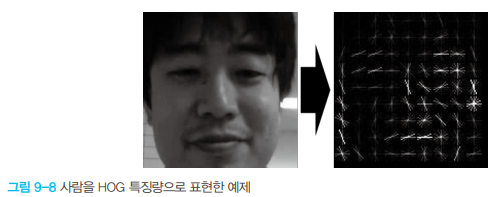

In [6]:
import cv2 

# HOGDescriptor 선언 + 사람 모델 지정
# 함수 : setSVMDetector
# 인수 : cv2.HOGDescriptor_getDefaultPeopleDetector()
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
hogParams = {'winStride' : (8, 8), 'padding' : (32, 32), 'scale' : 1.05, 'hitThreshold' : 0, 'groupThreshold' : 5}

# 읽어들인 이미지를 cv2Color를 이용해 흑백으로 변환한 후
# detectMultiScale로 사람을 검출
img = cv2.imread('./img/img01.jpg')
gray= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# human : 검출된 사람의 위치 정보
human, r = hog.detectMultiScale(gray, **hogParams)

# rectangle : 이미지에 사각형을 그리는 함수
if (len(human)> 0) :
  for (x, y, w, h) in human :
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 255), 3)

cv2.imshow('img', img)
cv2.waitKey(0)

-1

> #### 이미지 속 사람 '얼굴' 검출

In [ ]:
# 이미지 속 사람 '얼굴' 검출

# 얼굴 검출에는 전통적으로 CascadeClassifier를 사용
# 얼굴 검출 및 개인 인증은 많은 라이브러리가 공개되어 있기 때문에
# 여기서는 대략적인 흐름만 파악하고 전문 서적을 이용해 성능을 비교해 보는 것이 좋습니다.

import cv2

# CascadeClassifier 선언 및 'haarcascade_frontalface_alt.xml' 모델 지정
#(이는 정면 얼굴을 인식하는 모델)
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_alt.xml'
cascade = cv2.CascadeClassifier(cascade_path)

# 읽어들인 이미지를 cv2Color를 이용해 흑백으로 변환한 후
# detectMultiScale로 사람 '얼굴' 검출
img = cv2.imread('./img/img02.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# face_list : 검출된 사람 '얼굴'의 위치 정보
face_list = cascade.detectMultiScale(gray, minSize=(50, 50))

# 검출한 얼굴 표시
for (x, y, w, h) in face_list :
  color= (0, 0, 225) # red
  pen_w = 3
  cv2.rectangle(img, (x,y), (x+w, y+h), color, thickness= pen_w)

cv2.namedWindow('img', cv2.WINDOW_NORMAL)
cv2.imshow('img', img)
cv2.imwrite('./img/img02_face.jpg', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

> #### 이미지 속 사람의 얼굴이 <U>어느 쪽을 보고 있는지</U> 검출

In [5]:
# 사람, 얼굴뿐만 아니라 표정의 특징을 파악하는 것도 가능합니다.
# diib라는 라이브러리를 이용하면 얼굴의 눈,코,입,윤곽을 68개의 특징점으로 표현할 수 있습니다.
# 이것으로 사람의 얼굴이 어느쪽으로 돌리고 있는지를 검출할 수 있습니다.

In [ ]:
# dlib은 C++ 기반이기 때문에 

# !cd C:/dlib
# !pip install dlib-19.24.2-cp311-cp311-win_amd64.whl

# 실패

In [ ]:
# 설치 목적이 얼굴 인식이라면 dlib 대신 face_recognition, mediapipe, opencv 등 다른 고성능 라이브러리도 있습니다.

In [14]:
# # 구글이 만든 라이브러리
# !pip install numpy==1.26.4
# !pip install opencv-python==4.9.0.80

In [3]:
import cv2
import numpy as np

# 얼굴 탐지기 로드
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 일반적인 얼굴 모델 포인트 (Z: 깊이)
model_points = np.array([
    (0.0, 0.0, 0.0),           # Nose tip
    (0.0, -330.0, -65.0),      # Chin
    (-225.0, 170.0, -135.0),   # Left eye left corner
    (225.0, 170.0, -135.0),    # Right eye right corner
    (-150.0, -150.0, -125.0),  # Left mouth corner
    (150.0, -150.0, -125.0)    # Right mouth corner
])

# 이미지 불러오기

img = cv2.imread('./img/img02.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# faces : 검출된 사람의 얼굴 위치 정보
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

if len(faces) > 0:
    for (x, y, w, h) in faces:
        # 눈, 코, 입의 대략적인 위치 (비정확하지만 데모용)
        image_points = np.array([
            (x + w // 2, y + h // 2 - h // 6),          # nose tip
            (x + w // 2, y + h),                        # chin
            (x + w // 4, y + h // 3),                   # left eye left corner
            (x + 3 * w // 4, y + h // 3),               # right eye right corner
            (x + w // 4, y + 2 * h // 3),               # left mouth corner
            (x + 3 * w // 4, y + 2 * h // 3),           # right mouth corner
        ], dtype='double')

        # 이미지의 너비를 초점거리로 설정
        focal_length = img.shape[1]
        # 이미지의 중심 좌표
        center = (img.shape[1] / 2, img.shape[0] / 2) # center line
        # 3 x 3 내부 카메라 행렬로 초점 거리와 중심 좌표로 구성됨
        # 카메라 행렬 : 실제 3D 세계 좌표를 2D 이미지 좌표로 투영하는 데 사용하는 행렬
        camera_matrix = np.array([
            [focal_length, 0, center[0]],
            [0, focal_length, center[1]],
            [0, 0, 1]
        ], dtype='double')

        dist_coeffs = np.zeros((4, 1))

        # PnP로 회전/이동 벡터 계산
        # model_points : 일반적인 실제 3D 얼굴 모델의 좌표
        # image_points : 이미지에서 검출한 해당 포인트들의 2D 좌표
        # solvePnP : 주어진 2D-3D 대응점으로부터 회전 벡터와 이동 벡터를 추정
        success, rotation_vec, translation_vec = cv2.solvePnP(
            model_points, image_points, camera_matrix, dist_coeffs
        )
        
        # rotation_vec은 3D 공간에서 객체가 어떻게 회전했는지를 나타냄
        # 이를 Rodrigues 변환을 통해 3x3 회전 행렬로 변환합니다.
        # yaw : 좌우 회전
        # pitch : 상하 회전
        # roll : 기울기(기울임)

        # 회전 행렬 → 오일러 각
        # Rodrigues : 회전 벡터를 3 x 3 회전 행렬로 변환
        # RQDecomp3x3 : 회전 행렬을 오일러 각(roll, pitch, yaw)로 분해
        # 여기서 angle[1]은 yaw(수평 회전각, 즉 좌우 회전)를 의미
        rotation_mat, _ = cv2.Rodrigues(rotation_vec)
        angles, _, _, _, _, _ = cv2.RQDecomp3x3(rotation_mat)
        yaw = angles[1]

        if yaw < -10:
            direction = f'left {abs(round(yaw, 1))} deg'
        elif yaw > 10:
            direction = f'right {round(yaw, 1)} deg'
        else :
            direction = f'center {round(yaw, 1)} deg'

        # 시각화
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, direction, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

else:
    print("얼굴이 인식되지 않았습니다.")

cv2.imshow('Head Pose Estimation', img)
cv2.imwrite('./img/img02_headpose.jpg', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# # cf) dlib

# import cv2
# import dlib
# import math

# # shape_predictor로 68개의 얼굴 기관 모델을 불러옴
# # get_frontal_face_detector로 정면 얼굴 모델을 불러옴
# # 사진에서 68개의 얼굴 랜드마크와 정면을 검출

# # 이렇게 얻은 68개의 랜드마크로부터 얼굴의 방향을 계산
# # 윤곽 중심과 안쪽 중심의 차이로 얼굴의 방향을 계산

# predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')
# detector = dlib.get_frontal_face_detector()

# img = cv2.imread('img/img02.jpg')
# img_detect = detector(img, 1)

# for k, d in enumerate(img_detect) :
#   shape = predictor(img, d)
  
#   # 얼굴 영역 표시
#   color_f = (0, 0, 225)
#   color_l_out = (255, 0, 0)
#   color_l_in = (0, 255, 0)
#   line_w = 3
#   circle_r = 3
#   fontType = cv2.FONT_HERSHEY_SIMPLEX
#   fontsize = 1
  
#   cv2.rectangle(img, (d.left(), d.top()), (d.right(), d.bottom()), color_f, line_w) # red
#   cv2.putText(img, str(k), (d.left(), d.top()), fontType, fontsize, color_f, line_w) # 0 right 3.6 deg.

#   # 중심을 계산할 사각형 준비
#   num_of_points_out = 17
#   num_of_points_in = shape.num_parts - num_of_points_out
#   gx_out = 0
#   gy_out = 0
#   gx_in = 0
#   gy_in = 0
#   for shape_point_count in range(shape.num_parts) :
#     shape_point = shape.part(shape_point_count)
#     print('얼굴 랜드마크No. {} 좌표 위치: ({}, {})'.format(shape_point_count, shape_point.x, shape_point.y))
#     #얼굴 랜드마크마다 그리기
#     if shape_point_count<num_of_points_out :
#       cv2.circle(img (shape_point.x, shape_point.y), circle_r, color_l_out, line_w)
#       gx_out = gx_out + shape_point.x / num_of_points_out 
#       gy_out = gy_out + shape_point.y / num_of_points_out
#     else :
#       cv2.circle(img, (shape_point.x, shape_point.y), circle_r, color_l_in, line_w)
#       gx_in = gx_in + shape_point.x / num_of_points_in
#       gy_in = gy_in + shape_point.y / num_of_points_in
      
#   # 중심 위치 표시
#   cv2.circle(img, (int(gx_out), int(gy_out)), circle_r, (0, 0, 255), line_w)
#   cv2.circle(img, (int(gx_in), int(gy_in)), circle_r, (0, 0, 0), line_w)
  
#   # 얼굴 방향 표시
#   theta = math.asin(2*(gx_in - gx_out) / (d.right() - d.left())) 
#   radian = theta * 180/math.pi
  
#   print('얼굴방향 : {} (각도 : {}도)'.fotmat(theta, radian))
  
#   if radian <0 :
#     textPrefix= ' left '
#   else :
#     textPrefix = ' right '
#   textShow = textPrefix + str(round(abs(radian), 1)) + ' deg.'
#   cv2.putText(img, textShow, (d.left(), d.top()), fontType, fontsize, color_f, line_w)
  
# cv2.namedWindow('img', cv2.WINDOW_NORMAL)
# cv2.imshow('img', img)
# cv2.imwrite('dlib_head_position.jpg', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()  


ModuleNotFoundError: No module named 'dlib'

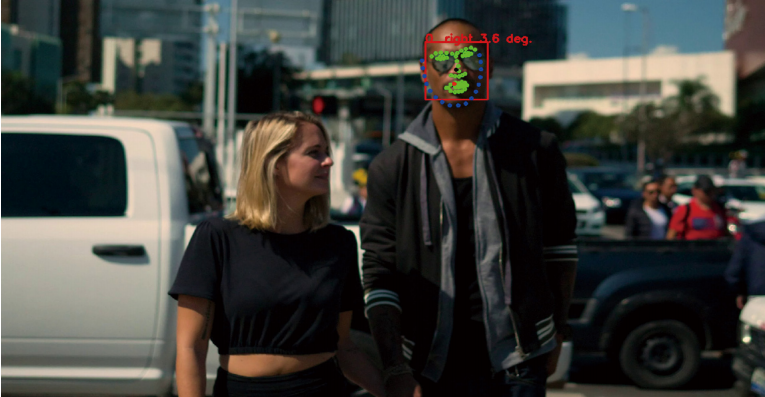

>  #### 검출한 정보를 종합해서 타입랩스 만들기

In [ ]:
# 타입랩스 생성

# 장시간 정보를 모두 눈으로 확인하려면 시간이 걸리지만 
# 간단하게 경향을 파악하는 데는 일정 기간의 프레임 중에서 1프레임만 꺼내는 '빠르게 재생하기'인 타임랩스가 적당합니다.

# 타임랩스는 데모 영상으로도 이용할 수 있고 분석 결과에 대한 설득력을 높이는 데 효과적입니다.

import cv2

print('타입랩스 생성 시작')

# 동영상 읽어오기
cap = cv2.VideoCapture('./mov/mov01.avi')
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# hog 선언
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
hogParams = {'winStride' : (8, 8), 'padding' : (32, 32), 'scale' : 1.05, 'hitThreshold' : 0, 'groupThreshold' : 5}

# 타입랩스 작성
movie_name = './mov/mov01_timelapse.avi'
fourcc = cv2.VideoWriter_fourcc(*'XVID')
video = cv2.VideoWriter(movie_name, fourcc, 30, (width, height))

num = 0
while (cap.isOpened()) :
  ret, frame = cap.read()
  if ret :
    if (num%10 == 0) : # 10커트 마다
      gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
      human, r = hog.detectMultiScale(gray, **hogParams)
      if len(human)>0 :
        for (x, y, w, h) in human :
          cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 255, 255), 3) # img, point1, point2, color, thickness
      
      # 10프레임마다 프레임 저장
      video.write(frame)
  else :
    break
  num = num + 1

video.release() # 동영상 생성
cap.release()
cv2.destroyAllWindows()
print('타임랩스 생성 완료')

타입랩스 생성 시작
타임랩스 생성 완료


In [ ]:
# 타입랩스를 만들려면 VideoWriter_fourcc 함수를 사용합니다.
# FourCC : 비디오 압축 코덱을 지정하기 위한 4개의 문자로 된 코드
# 여기서는 'X', 'V', 'I', 'D'로 4개의 파라미터를 지정해서 동영상 파일을 avi 형식으로 작성합니다.
# 'XVID' : Xvid MPEG-4 코덱
# 'MJPG' : Motion JPEG
# 'mp4v' : MPEG-4
# 'DIVX' : DivX

> #### 전체 모습을 그래프로 가시화

In [18]:
# 동영상에서 사람을 검출한 후 시계열로 저장해두면
# 그래프로 전체 모습을 표현하고 분석할 수 있습니다.

import cv2
import pandas as pd

print('분석 시작')
# 동영상 읽어오기
cap = cv2.VideoCapture('./mov/mov01.avi')
fps = cap.get(cv2.CAP_PROP_FPS) # 초당 프레임 수 > 시간 계산용

# hog 선언
# hogParmas
# 1) winStride : 사람 찾는 간격(검색 창이 이동하는 간격(가로, 세로)) - 8픽셀씩 움직임
# 2) padding : 주변에 추가로 잡는 여백 영역의 크기 - 주변 32픽셀을 여유 공간으로 두고 사람 인식
# 3) scale : 값이 작을수록 이미지 크기를 줄이며 여러 사이즈에 대한 사람 탐지 - 105%씩 축소 / 1.2는 120%씩 축소 축소하는 비율이 작을수록 정밀 탐색
# 4) hitThreshold : 결정 임계값 - 0보다 작을수록 더 많이 감지, 0보다 클수록 보수적으로 감지
# 5) groupThreshold : 여러 번 감지된 사각형을 하나로 통합할 때 필요한 최소 갯수 - 값이 클수록 오탐지 줄이지만 실제 사람도 놓칠 수 있음 / 값이 작을수록 감지는 잘하지만 중복 검출이 많을 수 있음
# (사각형이 여러 번 중첩되어 검출될 경우, 이 값을 넘는 그룹만 최종적으로 사람으로 판단)
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
hogParams = {'winStride' : (8, 8), 'padding' : (32, 32), 'scale' : 1.05, 'hitThreshold' : 0, 'groupThreshold' : 5}

num= 0
rows = []
while(cap.isOpened()) :
  ret, frame = cap.read()
  if ret :
    if (num%10 == 0) :
      gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
      human, r = hog.detectMultiScale(gray, **hogParams)
      if (len(human) > 0) :
        for (x, y, w, h) in human :
          cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 255, 255), 3)
      tmp_row = [num/fps, len(human)]
      rows.append(tmp_row)
      if cv2.waitKey(1) & 0xFF == ord('q') :
        break
  else :
    break
  num = num + 1

people_per_sec = pd.DataFrame(rows, columns= ['mov_sec', 'people_num'])

cap.release()
cv2.destroyAllWindows()
print('분석 종료')

분석 시작
분석 종료


In [ ]:
# num번째 프레임은 영상에서 몇 초 지점인가?
# fps = 30 > 1초에 30프레임
# num = 90
# > 이 프레임은 영상에서 ** 3초 지점 **
people_per_sec.head()

,mov_sec,people_num
0,0.000000,5
1,0.333333,11
2,0.666667,11
3,1.000000,7
4,1.333333,9


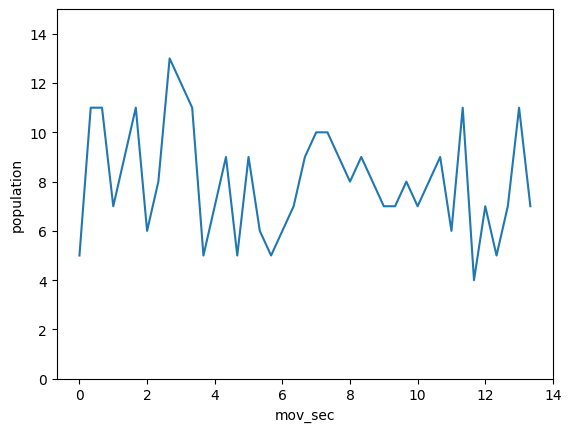

In [20]:
import matplotlib.pyplot as plt
plt.plot(people_per_sec['mov_sec'], people_per_sec['people_num'])
plt.xlabel('mov_sec')
plt.ylabel('population')
plt.ylim(0, 15)
plt.show()

> #### 거리의 변화를 그래프로 확인

In [23]:
# 다른 시간대에 촬영한 다른 동영상 mov02.avi를 불러들여 확인

import cv2
import pandas as pd

print('분석 시작')

cap = cv2.VideoCapture('./mov/mov02.avi')
fps = cap.get(cv2.CAP_PROP_FPS)

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
hogParams = {'winStride' : (8,8), 'padding' : (32, 32), 'scale' : 1.05, 'hitThreshold' : 0, 'groupThreshold' : 5}

num = 0
rows_2 = []
while(cap.isOpened()) :
  ret, frame = cap.read()
  if ret :
    if (num%10 == 0) :
      gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
      human, r = hog.detectMultiScale(gray, **hogParams)
      if (len(human) > 0) :
        for (x, y, w, h) in human :
          cv2.rectangle(frame, (x,y), (x+w, y+h), (255, 255, 255), 3)
      temp_row = [num/fps, len(human)]
      rows_2.append(temp_row)
      if cv2.waitKey(1) & 0xFF == ord('q') :
        break
  else :
    break
  num += 1

people_per_sec_2 = pd.DataFrame(rows_2, columns= ['mov_sec', 'people_num'])

cap.release()
cv2.destroyAllWindows()
print('분석 종료')

분석 시작
분석 종료


In [24]:
people_per_sec_2.head()

,mov_sec,people_num
0,0.000000,13
1,0.333333,14
2,0.666667,10
3,1.000000,8
4,1.333333,10


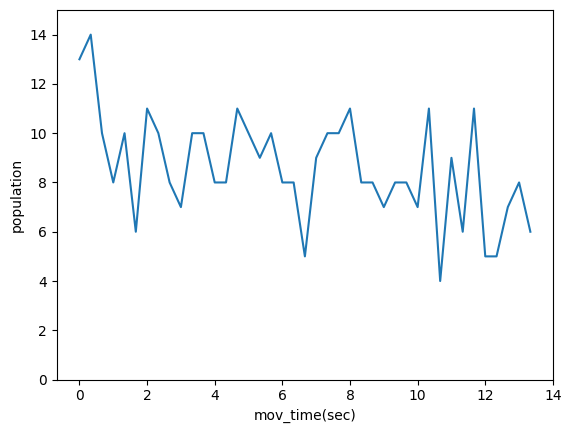

In [26]:
import matplotlib.pyplot as plt

plt.plot(people_per_sec_2['mov_sec'], people_per_sec_2['people_num'])
plt.xlabel('mov_time(sec)')
plt.ylabel('population')
plt.ylim(0, 15)
plt.show()

In [27]:
# mov01.avi와 비교해서 사람 수가 조금 늘어난 것 같은 느낌을 받습니다.
# 영상을 확인해 보면 후자는 카메라 근처에 사람이 몰려 있어 사람 수가 많이 카운트된 것으로 보입니다.
# 하지만 HOG로 분석한 데이터는 노이즈가 많고 오검출로 변동이 많은 그래프가 되어 그 차이를 확인하는 것이 어렵습니다.
# 다음에 이 영향을 제거하는 방법을 배워봅시다.

> #### 이동 평균을 계산해서 노이즈를 제거

In [ ]:
# 노이즈는 **계산하지 않아도 될 것을 계산해서 생기는 오차**입니다.
# 그렇게 생각하면 시간의 평균(이동 평균)을 계산하면
# 갑자기 사람의 숫자가 늘어나거나 줄어들어서 생기는 오차를 줄일 수 있을 것입니다.
# 함수 moving_average를 사용해서 이동 평균을 계산해 봅시다.

import numpy as np

# x : 시간
# y : 사람 수
def moving_average(x, y) :
  # convolve : 신호 처리 함수로 두 배열을 합성(컨볼루션)합니다.
  # np.ones(5)/5는 [1/5, 1/5, 1/5, 1/5, 1/5]이라는 평균 필터 커널을 의미 > 즉, 5개씩 평균내는 이동 평균을 계산
  # mode = 'valid' : 계산 가능한 구간만 결과로 반환 > 양 끝의 데이터는 부족해서 제외됨
  y_conv = np.convolve(y, np.ones(5)/float(5), mode= 'valid')
  # 이동 평균을 취한 결과는 원래보다 짧아지므로 그에 맞는 길이로 x축도 보정
  x_dat = np.linspace(np.min(x), np.max(x), np.size(y_conv))
  return x_dat, y_conv

# y = [3,4,5,2,7,8,4]
# y_conv : [(3+4+5+2+7)/5, (4+5+2+7+8)/5, (5+2+7+8+4)/5]
# len(y_conv) = len(y) - 4

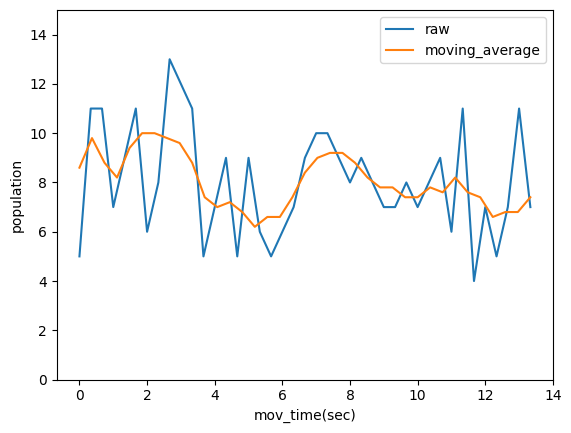

In [30]:
plt.plot(people_per_sec['mov_sec'], people_per_sec['people_num'], label= 'raw')
ma_x, ma_y = moving_average(people_per_sec['mov_sec'], people_per_sec['people_num'])
plt.plot(ma_x, ma_y, label= 'moving_average')
plt.xlabel('mov_time(sec)')
plt.ylabel('population')
plt.ylim(0, 15)
plt.legend()
plt.show()

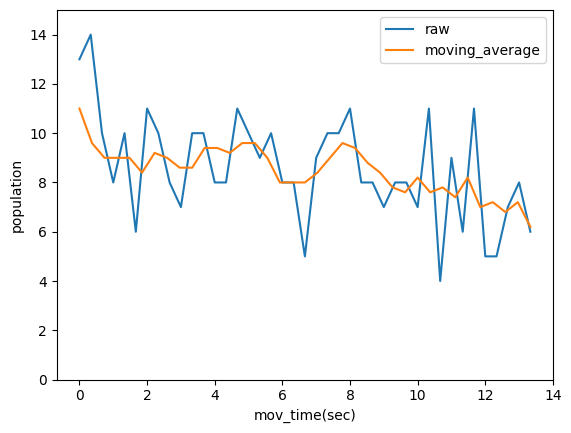

In [31]:
plt.plot(people_per_sec_2['mov_sec'], people_per_sec_2['people_num'], label= 'raw')

ma2_x, ma2_y = moving_average(people_per_sec_2['mov_sec'], people_per_sec_2['people_num'])

plt.plot(ma2_x, ma2_y, label= 'moving_average')
plt.xlabel('mov_time(sec)')
plt.ylabel('population')
plt.ylim(0, 15)
plt.legend()
plt.show()

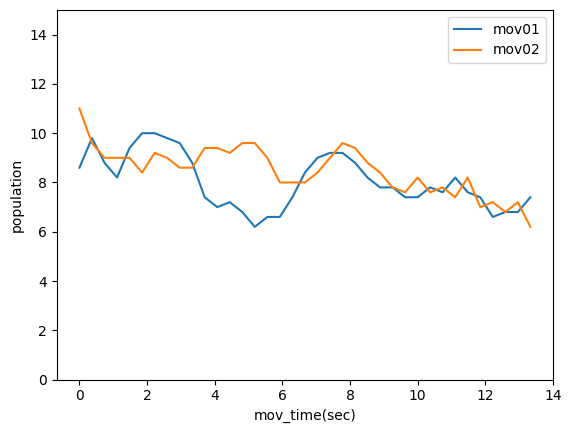

In [32]:
plt.plot(ma_x, ma_y, label= 'mov01')
plt.plot(ma2_x, ma2_y, label= 'mov02')
plt.xlabel('mov_time(sec)')
plt.ylabel('population')
plt.ylim(0, 15)
plt.legend()
plt.show()

In [ ]:
# 이렇게 이동 평균을 계산하면 '대충 mov02.avi쪽 사람이 많아 보인다'라는 느낌이 아니라
# 좀 더 정확하게 비교할 수 있습니다.
# 실제로 mov02.avi쪽이 카메라 근처에 사람이 많이 모여 있습니다.

# 이 모습을 정확하게 비교하기 위해서는
# 검출할 HOG의 크기를 검출하고 싶은 사람의 크기를 보고
# 어떤 크기 이상만 검출, 어떤 크기 이하는 무시하는 규칙을 푸함시키는 방법도 생각할 수 있습니다.